# ML Week 14: More Convolutions

Now that we have a nice solid foundation of convolutions, we are nearly ready to apply what we know about ANN to create our first convolutional neural network (CNN).

There are just a few small topics that we should touch on before we move ahead.

### Padding

When convolving, you saw that the size of the image decreases. In certain cases this may be undesireable.

Therefore, one common technique is known as "padding". This adds some pixels around the edge of an image.

Let's see what this looks like.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("art.png")[:,:,::-1]
img = cv2.resize(img, dsize=(256,256), interpolation = cv2.INTER_CUBIC)

# Note: this adds 10 pixels to all sides of the image.
# The final argument "BORDER_CONSTANT" simply sets these pixels to RGB=0,0,0 (black colour)
padded_img = cv2.copyMakeBorder(img, top=10, bottom=10, left=10, right=10, borderType=cv2.BORDER_CONSTANT)

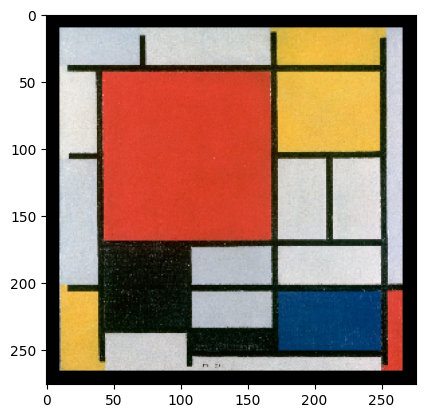

In [16]:
plt.imshow(padded_img)

### Pooling

There is a special type of layer which is almost always used in Convolutional Neural Networks. It is called a "Pooling Layer".

These layers are similar to convolutional layers, but their kernels* works differently. Instead of multiplying numbers together and then taking the sum, the kernel* simply chooses the maximum value (called "max pooling") or the mean value (called "mean pooling" or "average pooling").

This is another powerful way of eliminating redundant information and shrinking the size of large files.

<div>
<img src="./pooling.png" width="600"/>
</div>
Source: wikipedia

\* Technically speaking if there is not any multiplication it's not a proper kernel. "Filter" would be the correct term.

In [23]:
# We can apply pooling using the scikit-image library, which we will install here

%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from skimage.measure import block_reduce

mean_pool = block_reduce(img, block_size=(5,5,1), func=np.mean)
max_pool = block_reduce(img, block_size=(5,5,1), func=np.max)

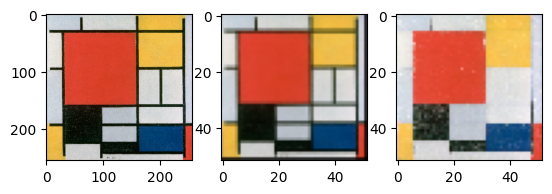

In [33]:
f, ax = plt.subplots(1,3)
im1 = ax[0].imshow(img)
im2 = ax[1].imshow(mean_pool.astype(int))  # Note: for plotting we need integers
im3 = ax[2].imshow(max_pool)

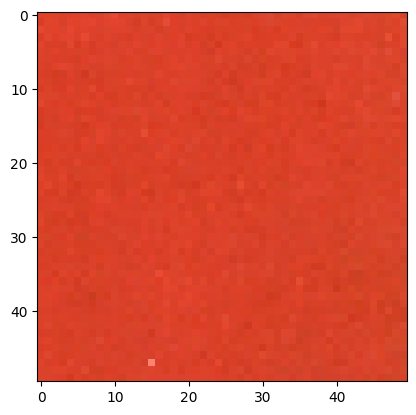

In [2]:
plt.imshow(img[50:100, 100:150])

### We can now understand CNN architectures

With all this we have the tools to look at Computer Vision publications and understand the architecture diagrams!

LeNet vs AlexNet

<div>
<img src="./LeNet_vs_AlexNet.png" width="300" style="background-color:white"/>
</div>

AlexNet
<div>
<img src="./AlexNet.png" width="800"/>
</div>

VGG 16

<div>
<img src="./VGG16.png" width="600"/>
</div>
Source: wikipedia

### PyTorch

Scikit Image and OpenCV allow us to play around with basic Computer Vision techniques.

But if we want to do proper hardcore Deep Learning we need one of the heavyweight libraries.

The current two are TensorFlow and PyTorch (often referred to as just "Torch").

The two are pretty neck and neck - in general PyTorch is a bit more prominent in research while TensorFlow is a bit more common in industry. But since 2025 Industry adoption has been huge.

For now we'll start with PyTorch.

<div>
<img src="./PyTorch_vs_TF.png" width="800"/>
</div>

In [24]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Let's just start with a super basic convolution example

import torch

inputs = torch.randn(3, 16, 16)  # Note: Often the convention is to write (1, 3, 16, 16)

# Dimensions represent: (kernels, channels, height, width)
filters = torch.randn(6, 3, 3, 3)

conv = torch.conv2d(inputs, filters, stride=2, padding=1)

In [42]:
conv.shape

torch.Size([6, 8, 8])

# Exercises

### Exercise 1

Opencv supports a wide variety of differnt padding methods. The full list is:

* cv2.BORDER_CONSTANT
* cv2.BORDER_REFLECT
* cv2.BORDER_REFLECT_101
* cv2.BORDER_DEFAULT
* cv2.BORDER_REPLICATE
* cv2.BORDER_WRAP

Try out some of them to see the effects they have.

### Exercise 2

The below code shows the PyTorch implementation of a simple Convolutional Neural Network.

Ignore the "\_\_init\_\_" and "super" stuff - this is related to software techniques.

Looking at the rest of the code, can you see the basic elements that make up the CNN?

We can't actually use this yet (for that we need data, among other things). We will get to that next class!

In [ ]:
from torch import nn

class ImageClassifier(nn.Module):  # Ignore this
    def __init__(self):  # Ignore this
        super(ImageClassifier, self).__init__()  # Ignore this
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3),
            nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 22 * 22, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x